# MathDial Dataset Example Usage
This notebook demonstrates basic usage of the MathDial dataset using ConvoKit.
We will explore the dataset size, teacher's pedagogical moves, and their correlation with successful student self-correction.


In [2]:
import convokit
from convokit import Corpus
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

# Load corpus
corpus = Corpus(filename="../mathdial_processing/mathdial-corpus")
corpus.print_summary_stats()


Number of Speakers: 1112
Number of Utterances: 35348
Number of Conversations: 2861


## 1. Teacher Pedagogical Moves
The expert human teachers use various pedagogical strategies to guide the AI student. Let's see the distribution of these moves.


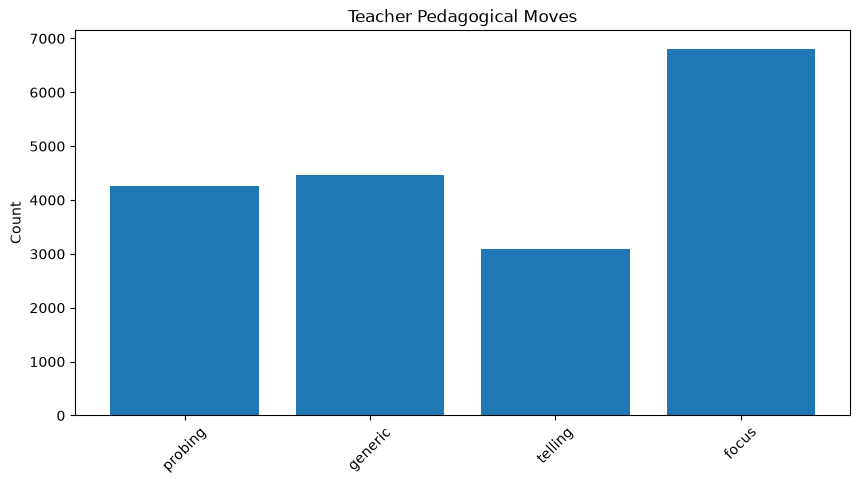

In [3]:
moves = Counter()
for utt in corpus.iter_utterances():
    if utt.speaker.id.startswith('teacher_'):
        move = utt.meta.get('pedagogical_move')
        if move:
            moves[move] += 1

plt.figure(figsize=(10, 5))
plt.bar(moves.keys(), moves.values())
plt.title("Teacher Pedagogical Moves")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


## 2. Correlation with Success
Does the teacher's choice of pedagogical moves correlate with the student successfully correcting their error? Let's analyze the average use of moves in successful vs unsuccessful sessions.


Successful sessions: 2129
Unsuccessful sessions: 732


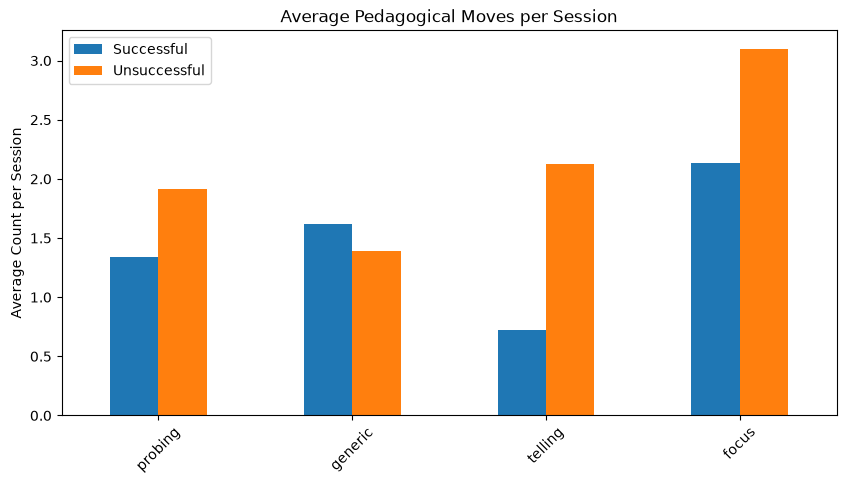

In [4]:
success_moves = Counter()
fail_moves = Counter()

success_count = 0
fail_count = 0

for convo in corpus.iter_conversations():
    is_success = convo.meta.get('success', False)
    if is_success:
        success_count += 1
    else:
        fail_count += 1
        
    for utt in convo.iter_utterances():
        if utt.speaker.id.startswith('teacher_'):
            move = utt.meta.get('pedagogical_move')
            if move:
                if is_success:
                    success_moves[move] += 1
                else:
                    fail_moves[move] += 1

print(f"Successful sessions: {success_count}")
print(f"Unsuccessful sessions: {fail_count}")

# Normalize by number of sessions
norm_success = {k: v / success_count for k, v in success_moves.items()}
norm_fail = {k: v / fail_count for k, v in fail_moves.items()}

df = pd.DataFrame({'Successful': norm_success, 'Unsuccessful': norm_fail}).fillna(0)
df.plot(kind='bar', figsize=(10, 5))
plt.title("Average Pedagogical Moves per Session")
plt.ylabel("Average Count per Session")
plt.xticks(rotation=45)
plt.show()


## 3. ConvoKitAI Feature: Conversation Aliases
MathDial uses ConvoKitAI formatting! One powerful feature is `Conversation.ai_meta['alias']`, which allows an AI agent (like `student_ai`) to have a unique human-readable name in the prompt context of each conversation.


In [1]:
from convokitai import Corpus as AICorpus

# Reload corpus using ConvoKitAI's Corpus
ai_corpus = AICorpus(filename="../mathdial_processing/mathdial-corpus")

# Check the AI student globally
student_ai = ai_corpus.get_speaker('student_ai')
print(f"Global AI Student: {student_ai.id}, is_ai: {student_ai.is_ai}, role: {student_ai.ai_meta.get('role')}")

# Check the conversation-level persona injected via alias
convo = next(ai_corpus.iter_conversations())
print(f"\nConversation ID: {convo.id}")
print(f"AI Meta Alias Map: {convo.ai_meta.get('alias')}")
print(f"In this specific conversation, 'student_ai' is named: {convo.ai_meta['alias']['student_ai']}")


Global AI Student: student_ai, is_ai: True, role: student

Conversation ID: session_train_0
AI Meta Alias Map: {'student_ai': 'Steven'}
In this specific conversation, 'student_ai' is named: Steven
